In [1]:
#imports
import os
import sys
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Get the current working directory
current_dir = os.getcwd()

if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.abspath(os.path.join(current_dir, '..'))
    os.chdir(project_root)
    print(f"Changed working directory to project root: {os.getcwd()}")
else:
    project_root = current_dir
    print(f"Already in project root: {project_root}")
    
from src.dataset import VehicleDataset
from src.utils import (
    list_files_in_subfolders,
    verify_image_label_pairs,
    visualize_images,
    visualize_augmented_batch
)

c:\Users\STUDENT\Downloads\unsafe_following_distance\idl_project_venv\lib\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Changed working directory to project root: c:\Users\STUDENT\Downloads\unsafe_following_distance


### Configuration

Define the paths to data and a `collate_fn` for PyTorch object detection DataLoaders.

In [2]:
base_dir = 'data/vehicle_data_raw/'
image_dir = os.path.join(base_dir, 'train', 'images')
label_dir = os.path.join(base_dir, 'train', 'labels')

def collate_fn(batch):
    """Custom collate function for object detection DataLoader."""
    return tuple(zip(*batch))

### Explore and Verify the Dataset

Run utility functions to get a feel for the data structure and confirm that every image has a matching label file.

In [3]:
list_files_in_subfolders(base_dir)


Folder: data/vehicle_data_raw/train
  -- labels.npy

Folder: data/vehicle_data_raw/train\images
  -- Highway_0_2020-07-30_jpg.rf.09e9d4467f17b2b870a5d1b94a38774a.jpg
  -- Highway_0_2020-07-30_jpg.rf.7d947cc31b302b22a527ecd17d3af963.jpg
  -- Highway_0_2020-07-30_jpg.rf.f2b27ff74487ea9a91b9dff189180e8d.jpg
  -- Highway_1000_2020-07-30_jpg.rf.9a2ce6acd2c0ffd57ab44a13f084b950.jpg
  -- Highway_1000_2020-07-30_jpg.rf.e9364fb1c7d1bf9f8cbea3d1c1575050.jpg

Folder: data/vehicle_data_raw/train\labels
  -- classes.txt
  -- Highway_0_2020-07-30_jpg.rf.09e9d4467f17b2b870a5d1b94a38774a.txt
  -- Highway_0_2020-07-30_jpg.rf.7d947cc31b302b22a527ecd17d3af963.txt
  -- Highway_0_2020-07-30_jpg.rf.f2b27ff74487ea9a91b9dff189180e8d.txt
  -- Highway_1000_2020-07-30_jpg.rf.9a2ce6acd2c0ffd57ab44a13f084b950.txt


In [4]:
verify_image_label_pairs(image_dir, label_dir)

Total images (.jpg) found: 8218
Total annotation files (.txt) found: 8218
Matching image/label pairs: 8218
Images without labels: 0
Labels without images: 0
All images have a corresponding label file.


In [5]:
!type data\vehicle_data_raw\train\labels\classes.txt

auto
bus
car
lcv
motorcycle
multiaxle
tractor
truck


### Load Class Names and Split Data

Load the class names from `classes.txt` and then split the list of image files into training and validation sets.

In [6]:
class_names_path = os.path.join(label_dir, 'classes.txt')
with open(class_names_path, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]
print(f"Loaded {len(class_names)} classes: {class_names}\n")

all_images = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])
train_files, val_files = train_test_split(all_images, test_size=0.2, random_state=42)

print(f"Total images: {len(all_images)}")
print(f"Training samples: {len(train_files)}")
print(f"Validation samples: {len(val_files)}")

Loaded 8 classes: ['auto', 'bus', 'car', 'lcv', 'motorcycle', 'multiaxle', 'tractor', 'truck']

Total images: 8218
Training samples: 6574
Validation samples: 1644


### Visualize Original Images

Let's look at a few random images from our training set with their original bounding boxes to see what the raw data looks like.

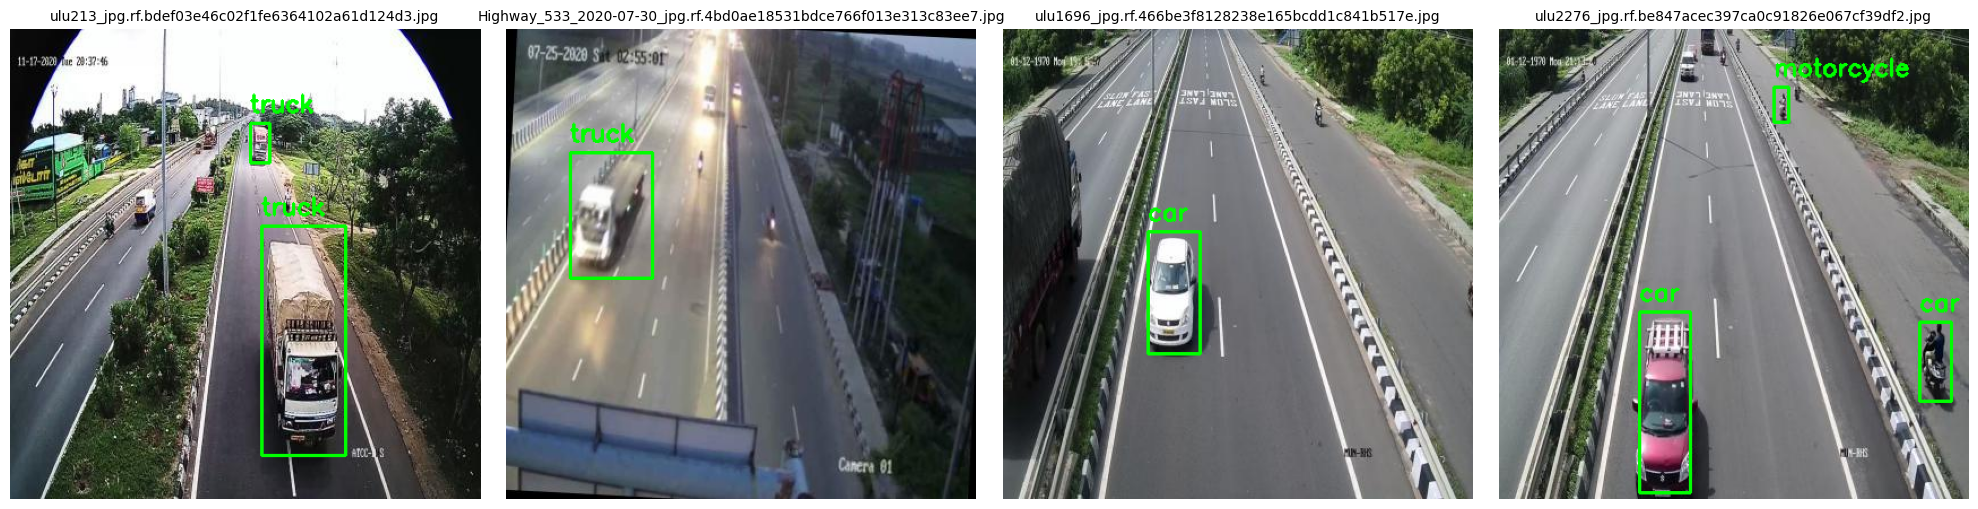

In [7]:
visualize_images(image_dir, label_dir, train_files, class_names, num_images=4)

### Augmentations and DataLoaders

Defining the data augmentation pipeline using `albumentations` and create the PyTorch `DataLoader` objects.

In [8]:
train_transforms = A.Compose([
    A.Resize(640, 640),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.RandomGamma(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet values
    ToTensorV2(),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

val_transforms = A.Compose([
    A.Resize(640, 640),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

#Dataset objects
train_dataset = VehicleDataset(image_dir, label_dir, train_files, transform=train_transforms)
val_dataset = VehicleDataset(image_dir, label_dir, val_files, transform=val_transforms)

#DataLoader objects
train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    num_workers=0, collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False,
    num_workers=0, collate_fn=collate_fn
)

print("\nDataLoaders are ready for training.")
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in val_loader: {len(val_loader)}")


DataLoaders are ready for training.
Number of batches in train_loader: 1644
Number of batches in val_loader: 411


### Visualize an Augmented Batch

Pull one batch from our `train_loader` and visualize it to confirm that augmentations are being applied correctly to both the images and their bounding boxes. 

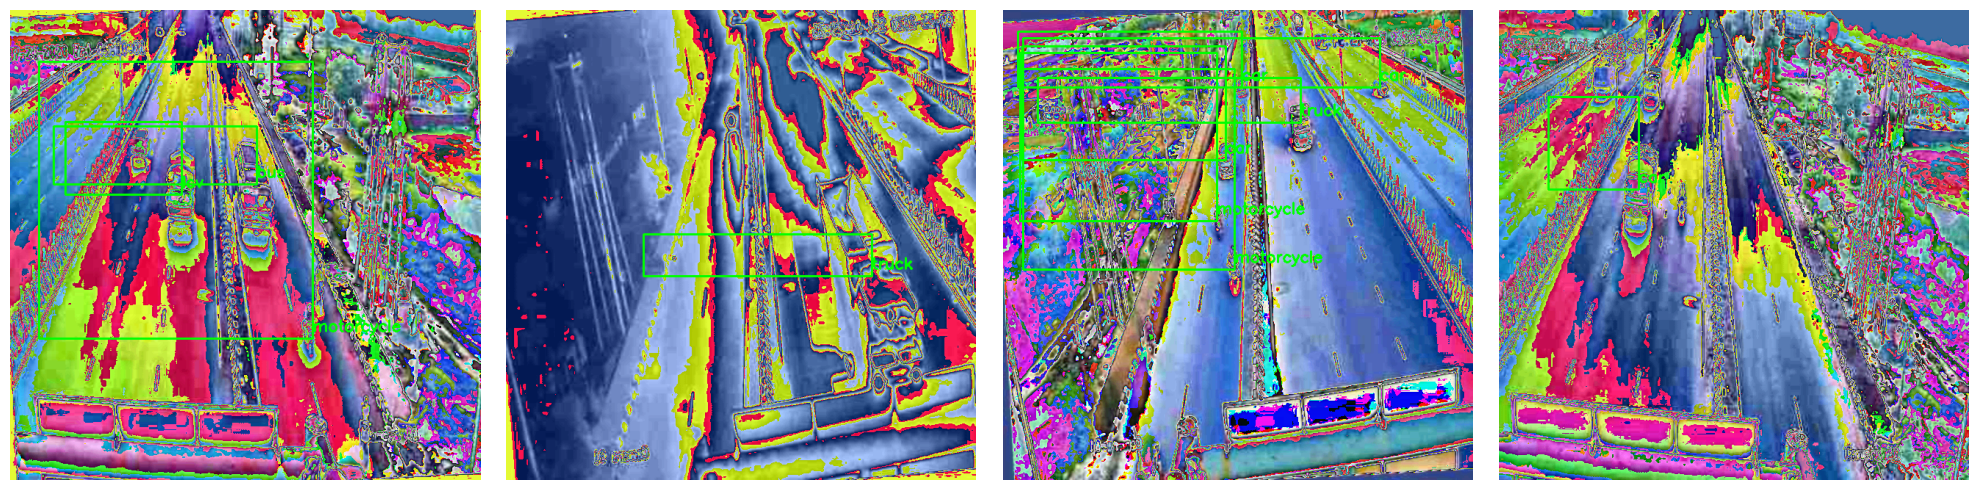

In [9]:
visualize_augmented_batch(train_loader, class_names, num_images=4)